Shape: (20640, 10)
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 

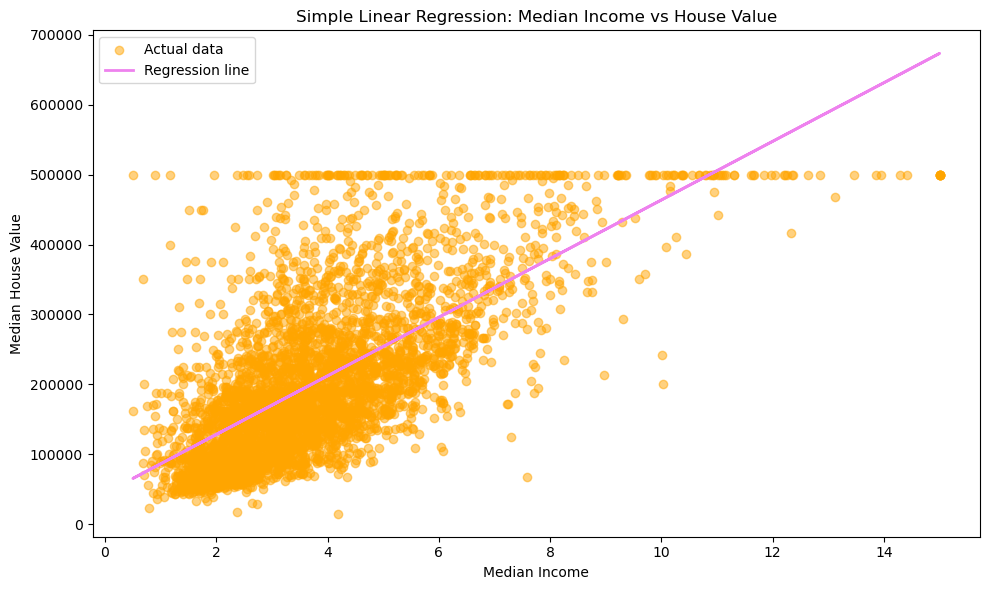

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ---------------------------------------------------------------
# 1. Load the dataset
# ---------------------------------------------------------------
df = pd.read_csv("housing.csv")   # change path if needed

print("Shape:", df.shape)
print(df.head())
print(df.info())
print(df.isnull().sum())

# 2. Basic cleaning

df = df.dropna(subset=["median_income", "median_house_value"])


# 3. Select feature (X) and target (y)

X = df[["median_income"]]        
y = df["median_house_value"]   


#4. Train/test split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ---------------------------------------------------------------
# 5. Fit Simple Linear Regression
# ---------------------------------------------------------------
model = LinearRegression()
model.fit(X_train, y_train)

# ---------------------------------------------------------------
# 6. Predict on test data
# ---------------------------------------------------------------
y_pred = model.predict(X_test)

# ---------------------------------------------------------------
# 7. Evaluate
# ---------------------------------------------------------------
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\n--- Model Results ---")
print(f"Slope (coefficient):  {model.coef_[0]:.4f}")
print(f"Intercept:            {model.intercept_:.4f}")
print(f"MAE:                  {mae:.4f}")
print(f"MSE:                  {mse:.4f}")
print(f"RMSE:                 {rmse:.4f}")
print(f"R2 Score:             {r2:.4f}")

# ---------------------------------------------------------------
# 8. Visualize the regression line
# ---------------------------------------------------------------
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, alpha=0.5, label="Actual data",color='ORANGE')
plt.plot(X_test, y_pred, color="VIOLET", linewidth=2, label="Regression line")
plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.title("Simple Linear Regression: Median Income vs House Value")
plt.legend()
plt.tight_layout()
plt.savefig("simple_linear_regression_plot.png", dpi=150)
plt.show()